In [3]:
import pandas as pd
import numpy as np

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()

prices.head()


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


Correlation Stuff

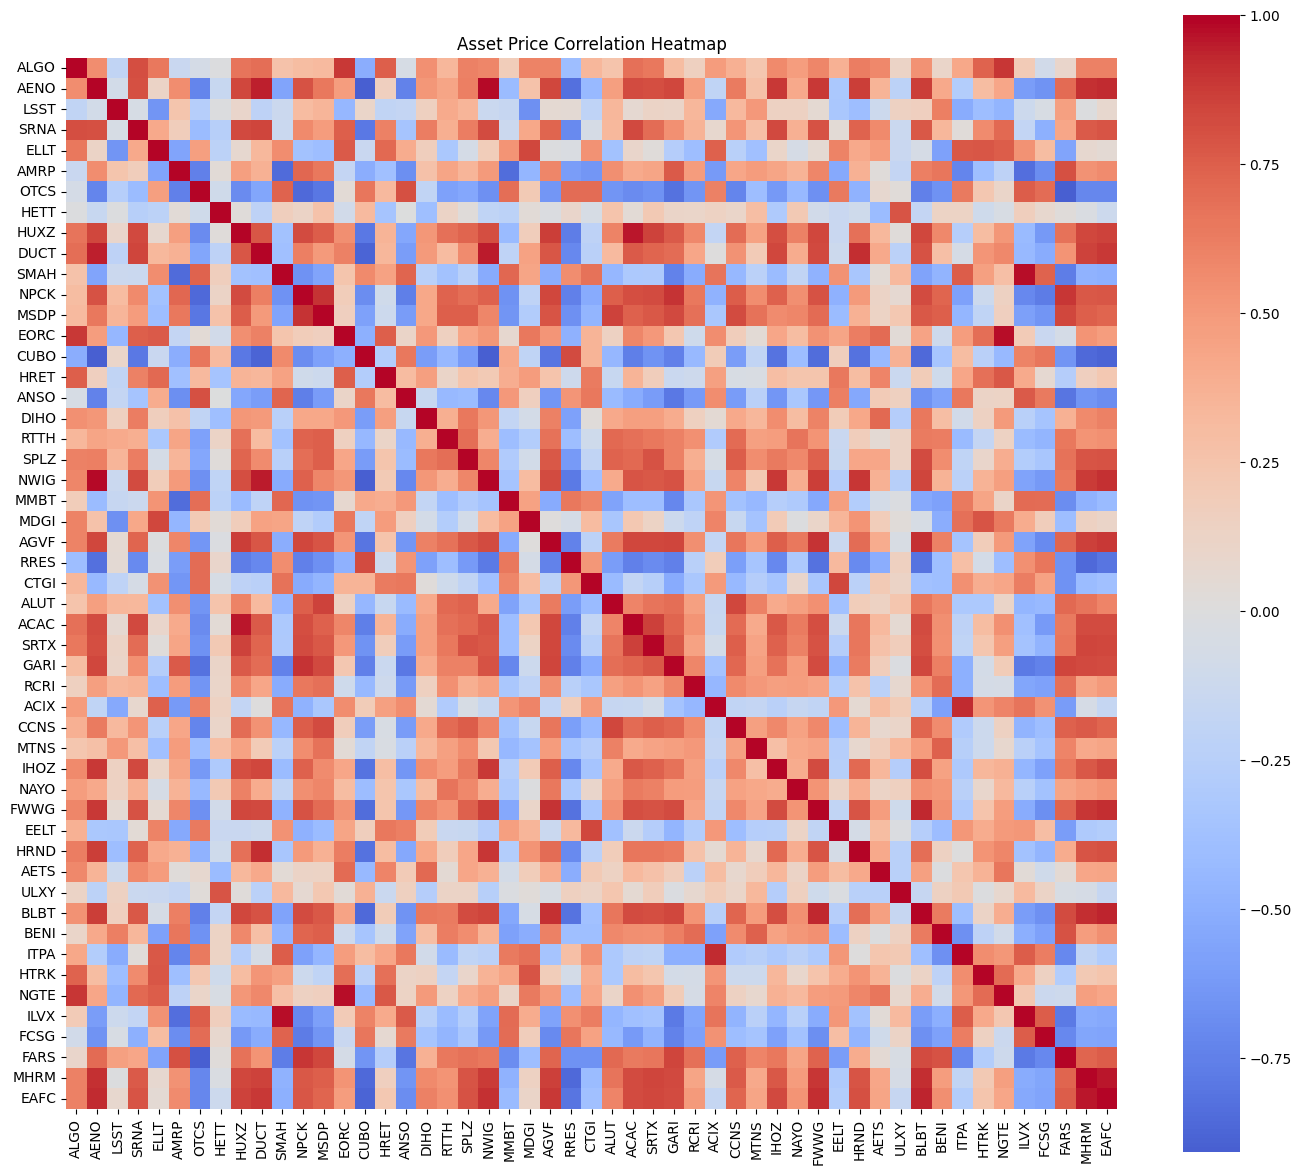

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

prices_corr = prices.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(prices_corr, cmap="coolwarm", center=0, square=True)
plt.title("Asset Price Correlation Heatmap")
plt.tight_layout()
plt.show()

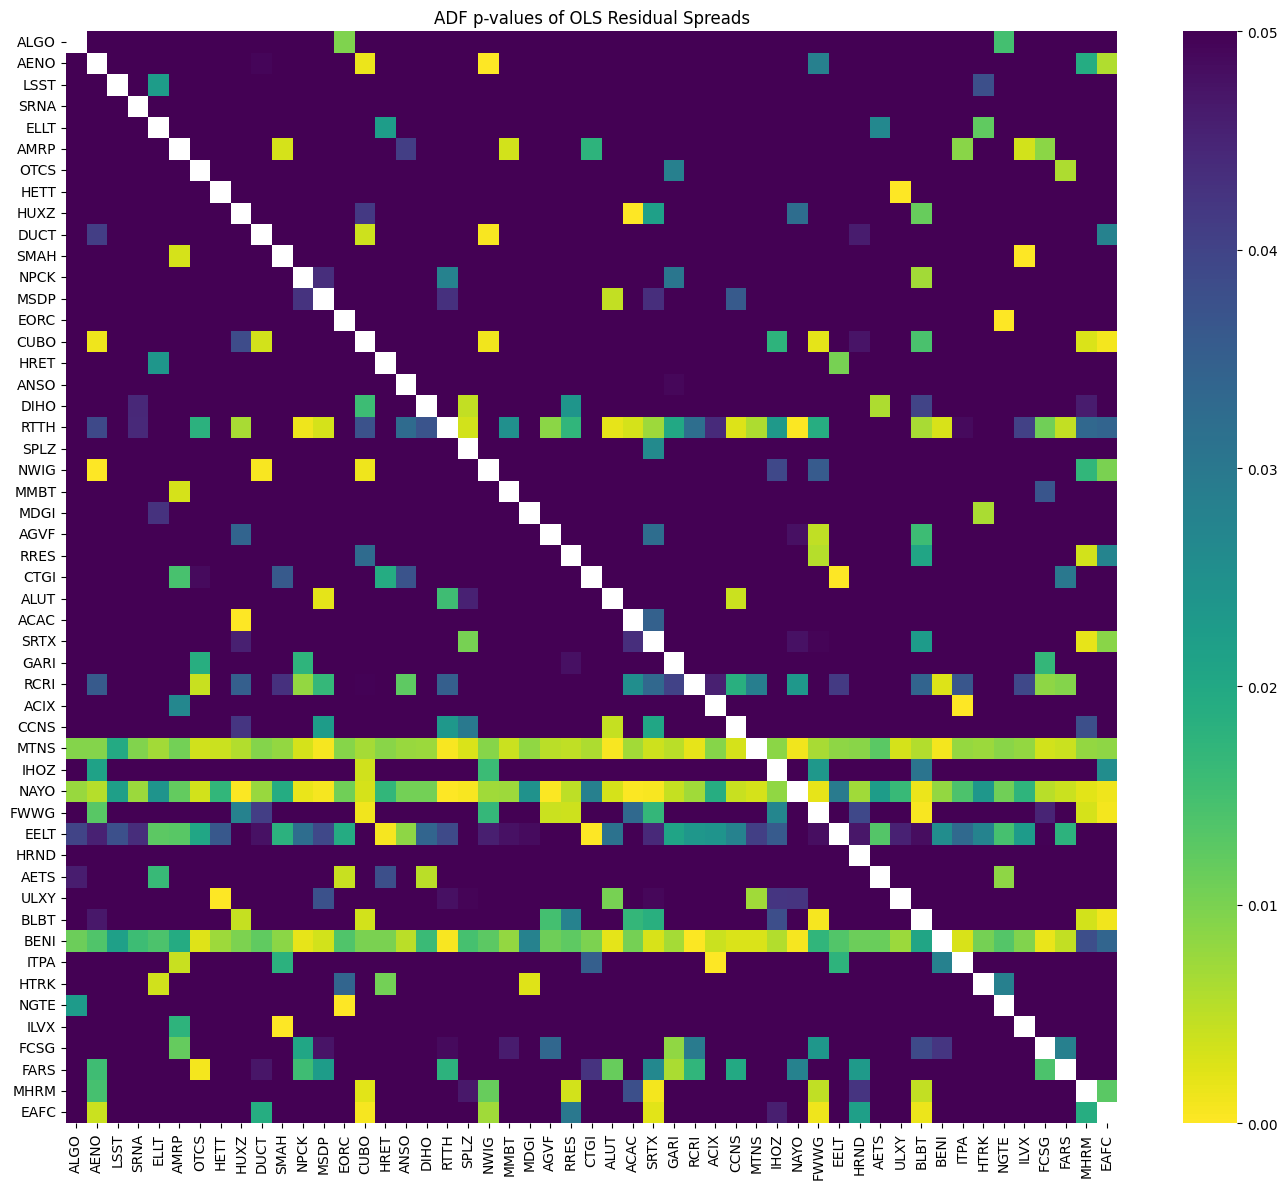

In [9]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

prices = pd.read_csv("prices.txt", sep=r"\s+")
assets = prices.columns

hedge_ratios = pd.DataFrame(index=assets, columns=assets, dtype=float)
adf_pvals = pd.DataFrame(index=assets, columns=assets, dtype=float)

for y_name in assets:
    for x_name in assets:
        if y_name == x_name:
            continue

        y = prices[y_name]
        x = sm.add_constant(prices[x_name])

        model = sm.OLS(y, x).fit()
        beta = model.params[x_name]
        spread = model.resid

        hedge_ratios.loc[y_name, x_name] = beta
        adf_pvals.loc[y_name, x_name] = adfuller(spread.dropna())[1]

plt.figure(figsize=(14, 12))
sns.heatmap(adf_pvals, cmap="viridis_r", vmin=0, vmax=0.05)
plt.title("ADF p-values of OLS Residual Spreads")
plt.tight_layout()
plt.show()